# PINN Showcase for Hysteresis Droplet (Fig 6)

## Introduction:
This notebook goes over the training process for hysteresis droplet shown in Fig 6 in our paper.

## Import Packages:
The packages below are used to compile the notebook.

In [ ]:
## Import necessary packages.
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..')))

from PINN_Drop.pinn_model import PINNDrop
import PINN_Drop.utils as utils
from PINN_Drop.train import train_hysteresis_pinn
import PINN_Drop.visualization as viz

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.path.abspath(os.path.join('.', '..'))

## Model Initialization and Training:
We simulate a droplet formed on a surface with a 30 degrees tilt, an advancing angle of 89 degrees, and a receding angle of 20 degrees. The Bond number of experiment is approximately 2.9. The following is the experimental image of the droplet formed under these conditions.

<p align="center">
    <img src="../figures/experimental_hysteresis_droplet.png" width="650" />
</p>

To simulate a hysteresis droplet, we use loss weights [PDE: 100, Volume: 1000, Angle: 1000, Motion: 100, Center: 0, y-center: 100].

In [ ]:
## Intialize the physics-based parameters for the hysteresis droplet.
args = utils.get_pinn_args(Bo = 2.9, surface_angles = [], high_angle = 89, low_angle = 20, 
                           tilt_angle = 30, weight_list = [100, 1000, 1000, 100, 0, 100])

To train the model, we'll use the weights of the droplet formed on a flat surface with Bond number 2.9 instead of loading in the warm-up weights. This way, the model will only learn the morphology of the droplet when tilt is introduced instead of training from scratch.

In [3]:
pinn = PINNDrop(args)

pinn.load_weights(model_weights = os.path.join(base_dir, 'saved_models', 'PINN_model_Bo_2_9.keras'), 
                  laplace_weights = os.path.join(base_dir, 'saved_models', 'PINN_state_Bo_2_9.npz'))

metrics = train_hysteresis_pinn(pinn, lr = 1e-4, total_epochs = 15000, eval_model = True)

## Results:
The following shows the results of our simulated hysteresis droplet. The plot below displays the 3D plot of the droplet, the 2D top-view of the droplet, the PDE loss, and the z-profile over the 15000 training epochs.

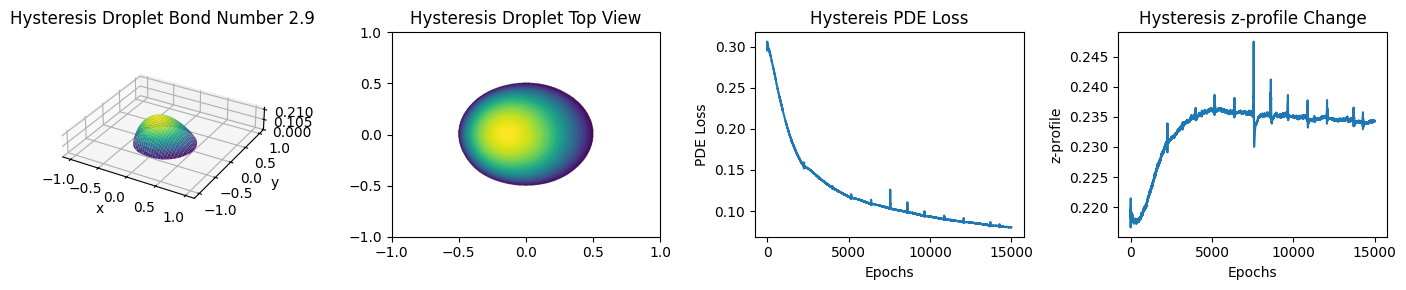

In [25]:
## Use 640 grid points for visualization.
num_grids = 640
z_pred = pinn.predict(utils.get_coords(pinn.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)

fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (14, 3))

ax[0].remove()
ax[0] = fig.add_subplot(1, 4, 1, projection = '3d')
viz.plot_droplet(ax[0], z_pred, pinn.space_width, num_grids, 
                 "Hysteresis Droplet Bond Number 2.9", "x", "y")

## Obtain xyz grid values for top view plotting.
x = np.linspace(-1, 1, 640)
y = np.linspace(-1, 1, 640)
X, Y, Z = utils.get_xyz_coords(z_pred, pinn.space_width, 640)

ax[1].imshow(Z, extent = [x.min(), x.max(), y.min(), y.max()], origin = 'lower', aspect = 'auto')
ax[1].contour(X, Y, Z, levels = 12, linewidths = 0.5)
ax[1].set_title("Hysteresis Droplet Top View")

ax[2].plot(range(15000), metrics['pde_loss'])
ax[2].set_xlabel("Epochs")
ax[2].set_ylabel("PDE Loss")
ax[2].set_title("Hystereis PDE Loss")

ax[3].plot(range(15000), metrics['z_profile'])
ax[3].set_xlabel("Epochs")
ax[3].set_ylabel("z-profile")
ax[3].set_title("Hysteresis z-profile Change")

plt.tight_layout()
plt.show()

We've provided the experimental z-profiles labeled as ``experimental_z_profiles.csv``. Below shows our predicted z-profile overlaid with the experimental z-profiles.

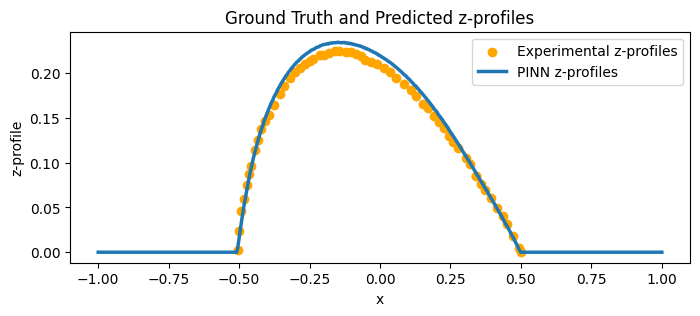

In [23]:
hysteresis_experimental = pd.read_csv(os.path.join(base_dir, 'data', 'experimental_z_profiles.csv'), header = None)
x_full, y_full, z_y_slice, z_x_slice, z_max, z_min = utils.get_zx_zy_coords(z_pred, pinn.space_width, num_grids)

plt.figure(figsize = (8, 3))
plt.scatter(hysteresis_experimental[0], hysteresis_experimental[1], color = 'orange', label = "Experimental z-profiles")
plt.plot(x_full, z_x_slice, label = "PINN z-profiles", linewidth = 2.5)
plt.title("Ground Truth and Predicted z-profiles")
plt.xlabel("x")
plt.ylabel("z-profile")
plt.legend()
plt.show()